# Peers given the formula's symbols copy its errors: Candidate-Signature Consensus (CSC)

This notebook is a runnable demo of **T6-E (iteration 4, development set E): Candidate-Signature Consensus (CSC)**. CSC is a
gold-free score for a natural-language → first-order-logic (NL→FOL) candidate.

**What `c_csc` measures.** Take a sentence `text` and a candidate formula `fol`. Three cheap peer LLMs from vendor families
different from the candidate's (DeepSeek-V3.2 / Phi-4 / GPT-4.1-mini / Qwen3-235B) translate `text` with the dataset-E
few-shot prompt, **plus a list of the candidate's own predicate/constant symbols**. Each peer formula is then checked with z3
for logical equivalence to the candidate. Symbols are matched only by lowercased name and arity; no aligner is used.

`c_csc = 1 − (share of usable peers z3-equivalent to the candidate)`. **Higher = more likely an ERROR.**

**The comparison.** The same peer families also translated each sentence *without* the symbol list. These are the
"FREE-matched" peers, and scoring the candidate against them with the same exact z3 test gives `c_free_exact`.

**Headline result of the full artifact (a negative result):** giving peers the symbol list lowers correct-row divergence
`d` (0.139 vs 0.323) but raises error endorsement `e` (0.459 vs 0.173). The peers **anchor** on the candidate's
vocabulary and copy its errors. On the 354-row PRIMARY population, stratified AUROC is 0.614 for `c_csc` vs 0.770 for
FREE-matched exact (paired delta −0.156, CI [−0.290, −0.031]).

**What this notebook does (no paid API calls):**
1. Defines the CSC library (`src/csc.py`, copied verbatim) and the few vendored parser, z3 and fingerprint helpers it needs.
2. Rebuilds each peer prompt byte-for-byte. It checks the prompt's sha1 key against the artifact's LLM cache, then replays
   the cached peer response. The cache is the only copy of the 599 paid peer generations.
3. Rescores `c_csc` and `c_free_exact` with z3 on a 100-row stratified subset of PRIMARY (`mini_demo_data.json`).
4. Computes the stratified AUROC, the error-endorsement / correct-divergence (`e`/`d`) decomposition and the paired delta,
   then plots them.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru -- NOT pre-installed on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, matplotlib -- pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
# --- original imports of src/csc.py and method.py ---
from __future__ import annotations

import hashlib
import json
import os
import random
import re
import signal
import sys
import time
from pathlib import Path

from loguru import logger

# --- imports of the vendored helpers (vendor_e/fol.py, peer_text.py) ---
import z3

# --- additional imports for the notebook (namespaces for the vendored helpers, analysis, plots) ---
import types
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

sys.setrecursionlimit(20000)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-4/experiment-9/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("rows:", len(data["rows"]), "| ERROR rows:", sum(r["y_R_AB"] for r in data["rows"]),
      "| cached peer responses:", len(data["llm_cache"]))

CSC demo subset: 100 PRIMARY R_AB rows of development set E (stratified over stratum x label), with the cached raw responses of the 3 family-disjoint CSC peers (results/llm_cache.jsonl), the free (no-signature) few-shot peers, the dataset-E few-shot prompt, and the artifact's stored scores for comparison. y_R_AB = 1 means ERROR.
rows: 100 | ERROR rows: 48 | cached peer responses: 212


## Configuration

Every tunable parameter lives here. Values from the original run are given in the comments.

- `N_ROWS`: how many of the 100 demo rows to score. The original scored all 354 PRIMARY rows (plus 2,686 FULL rows for the
  $0 FREE arm). Rows are taken in a fixed order that mixes strata and labels.
- `Z3_TIMEOUT_MS` / `Z3_CAP_S`: the per-pair z3 timeout and the wall-clock cap, both as in the original (2000 ms / 20 s).
  An UNKNOWN result counts as *not equivalent*.
- `K_PEERS`: family-disjoint peers per candidate (3, as in the original).
- `GRADED`: `c_csc_graded` (claim-unit F1) needs the ~1,000-line `peer_text` claim-unit / entailment engine, which is not
  inlined here. It must stay `False` in this notebook; the stored `c_csc_graded` values are shown for reference.
- `N_BOOT`: bootstrap replicates for the sentence-clustered confidence intervals. The original used 2,000.
- `ENDORSE_THRESHOLD`: a peer rule *endorses* a candidate when `c <= 0.5`, as in the original analysis.

In [5]:
N_ROWS = 100            # rows of mini_demo_data.json to score (max 100; original PRIMARY = 354)
Z3_TIMEOUT_MS = 2000   # z3 timeout per equivalence check (original: 2000)
Z3_CAP_S = 20          # SIGALRM wall-clock cap per check (original: 20)
K_PEERS = 3            # family-disjoint peers per candidate (original: 3)
GRADED = False         # c_csc_graded needs the peer_text claim-unit engine (not inlined) -> keep False
N_BOOT = 2000           # sentence-cluster bootstrap replicates (original: 2000)
ENDORSE_THRESHOLD = 0.5  # endorsed iff c <= 0.5 (original)
SEED = 0

## The pipeline entry point (`method.py`)

In the artifact, `method.py` is a thin stage runner. It calls each stage script in a subprocess with `PYTHONHASHSEED=0`,
and every LLM call is disk-cached in `results/llm_cache.jsonl`. Its stage table is copied below for orientation. A notebook
cannot run those subprocess scripts, so the cells that follow run the relevant work inline:
- the peer-generation part of `full` (OWN arm), replayed from the cache;
- the scoring part of `score` (OWN and FREE arms);
- the core AUROC and `e`/`d` part of `analyse`.

In [6]:
# method.py (stage table, verbatim). Each stage is `python <script> [args]` run from the artifact root.
STAGES = {"prep": ["src/prep.py"], "pilot": ["src/pilot.py"], "prereg": ["src/gen.py", "prereg"], "mini": ["src/gen.py", "mini"],
          "full": ["src/gen.py", "full"], "repro": ["src/repro.py"], "score": ["src/score.py"], "analyse": ["src/analyse.py"],
          "posthoc": ["src/posthoc_contam.py"], "report": ["src/report.py"], "audit": ["src/audit_rederive.py"], "audit_extra": ["src/audit_rederive.py", "extra"], "test": ["-m", "pytest", "-q", "-c", "pytest.ini", "tests"]}
# default when run with no arguments: the $0 stages
DEFAULT_STAGES = ["repro", "score", "analyse", "posthoc", "report"]
for st, cmd in STAGES.items():
    print(f"{st:12s} -> {' '.join(cmd)}")
print("default:", DEFAULT_STAGES, "| in this notebook: full(OWN, cached) -> score(OWN, FREE) -> analyse(AUROC, e/d)")

prep         -> src/prep.py
pilot        -> src/pilot.py
prereg       -> src/gen.py prereg
mini         -> src/gen.py mini
full         -> src/gen.py full
repro        -> src/repro.py
score        -> src/score.py
analyse      -> src/analyse.py
posthoc      -> src/posthoc_contam.py
report       -> src/report.py
audit        -> src/audit_rederive.py
audit_extra  -> src/audit_rederive.py extra
test         -> -m pytest -q -c pytest.ini tests
default: ['repro', 'score', 'analyse', 'posthoc', 'report'] | in this notebook: full(OWN, cached) -> score(OWN, FREE) -> analyse(AUROC, e/d)


## Vendored helper 1: the dataset-E FOL parser and z3 equivalence (`vendor/e8src/vendor_e/fol.py`)

This is the parser that produced dataset E's UNPARSEABLE labels. It turns Unicode FOL (FOLIO/MALLS notation) into a tuple
AST: `("atom", name, args)`, `("all"/"ex", var, body)`, `("not", e)` or `(op, lhs, rhs)`. It then translates that AST to
z3 over an uninterpreted sort `U`. Only the functions CSC uses are copied (`tokenize`, `Parser`, `parse`, `preds`, `to_z3`,
`mkpred`, `valid`, `equivalent`), and they are verbatim.

In [7]:
# ---- vendor_e/fol.py (verbatim subset) ----
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
IDENT = re.compile(r"^[A-Za-z_][A-Za-z0-9_'\-]*$")
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}  # FIX (gen_art_dataset_1): ⊕ moved to the ∨ level, binds tighter than →


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("<->", "↔").replace("->", "→").replace("&", "∧").replace("|", "∨")  # FIX: <-> before ->
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if name is None or not IDENT.match(name):  # FIX (gen_art_dataset_1): truncated input used to yield atom None
            raise ValueError(f"expected identifier, got {name!r}")
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            if any(a is None or not IDENT.match(a) for a in args):
                raise ValueError(f"bad argument list {args!r}")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)

## Vendored helper 2: canonical printing (`peer_text.py`) and symbols plus random-model fingerprint (`repair_census.py`)

- `parse_fol` / `to_str` / `alpha` / `canon` (from `peer_text.py`) give each formula an alpha-normalised canonical string.
  Bound variables become `v0, v1, …`, so two formulas that differ only in variable names get the same string.
- `symbols` (from `repair_census.py`) returns the predicate `(name, arity)` set and the constants of a formula.
- `fp` (from `repair_census.py`) evaluates the formula in 24 pseudo-random interpretations over a 3-element domain. If two
  formulas get different fingerprints they are certainly **not** equivalent, so z3 is only called when the fingerprints
  match. `fp` uses Python's `hash()`, which is why the artifact runs with `PYTHONHASHSEED=0`. Inside one process `hash()` is
  deterministic, so the equivalence verdicts do not depend on the seed.

These functions are copied verbatim. They are then bundled into the module names `csc.py` imports (`PT`, `EFOL`, `RC`), so
the CSC code below stays unchanged.

In [8]:
# ---- peer_text.py (verbatim subset) ----
BINSYM = {"iff": "↔", "xor": "⊕", "imp": "→", "or": "∨", "and": "∧"}


def parse_fol(s: str | None):
    """Dataset-E parser. Returns the AST or None (unparseable = coverage failure, never silently dropped)."""
    if s is None or not str(s).strip():
        return None
    try:
        return EFOL.parse(str(s))
    except (ValueError, IndexError, RecursionError, TypeError):
        return None


def to_str(e) -> str:
    """Fully parenthesised Unicode rendering; parse_fol(to_str(e)) == e."""
    k = e[0]
    if k == "atom":
        return f"{e[1]}({', '.join(e[2])})" if e[2] else e[1]
    if k in ("all", "ex"):
        return f"{'∀' if k == 'all' else '∃'}{e[1]} ({to_str(e[2])})"
    if k == "not":
        return f"¬({to_str(e[1])})" if e[1][0] not in ("atom", "not") else f"¬{to_str(e[1])}"
    return f"({to_str(e[1])} {BINSYM[k]} {to_str(e[2])})"


def alpha(e, env=None, ctr=None):
    """Alpha-normalise bound variables to v0, v1, ... in order of their binders (canonical strings; unique binders)."""
    env = {} if env is None else env
    ctr = [0] if ctr is None else ctr
    k = e[0]
    if k == "atom":
        return ("atom", e[1], tuple(env.get(a, a) for a in e[2]))
    if k in ("all", "ex"):
        nv = f"v{ctr[0]}"
        ctr[0] += 1
        return (k, nv, alpha(e[2], {**env, e[1]: nv}, ctr))
    if k == "not":
        return ("not", alpha(e[1], env, ctr))
    return (k, alpha(e[1], env, ctr), alpha(e[2], env, ctr))


def canon(e) -> str:
    return to_str(alpha(e))


# ---- vendor_c/repair_census.py (verbatim subset) ----
def atoms(e, acc=None):
    acc = [] if acc is None else acc
    if e[0] == "atom":
        acc.append(e)
    elif e[0] in ("all", "ex"):
        atoms(e[2], acc)
    elif e[0] == "not":
        atoms(e[1], acc)
    else:
        atoms(e[1], acc); atoms(e[2], acc)
    return acc


def bound_vars(e, acc=None):
    acc = set() if acc is None else acc
    if e[0] in ("all", "ex"):
        acc.add(e[1]); bound_vars(e[2], acc)
    elif e[0] == "not":
        bound_vars(e[1], acc)
    elif e[0] != "atom":
        bound_vars(e[1], acc); bound_vars(e[2], acc)
    return acc


def symbols(e):
    bv = bound_vars(e)
    P, C = {}, set()
    for a in atoms(e):
        P[(a[1], len(a[2]))] = True
        for x in a[2]:
            if x not in bv:
                C.add(x)
    return set(P), C


SEEDS = list(range(24))


def ev(e, m, env, dom, seed):
    k = e[0]
    if k == "atom":
        args = tuple(env[x] if x in env else (hash((seed, "c", x)) % dom) for x in e[2])
        return (hash((seed, e[1], len(e[2]), args)) >> 3) & 1 == 1
    if k == "all":
        return all(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "ex":
        return any(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "not":
        return not ev(e[1], m, env, dom, seed)
    a, b = ev(e[1], m, env, dom, seed), ev(e[2], m, env, dom, seed)
    return {"and": a and b, "or": a or b, "imp": (not a) or b, "iff": a == b, "xor": a != b}[k]


def fp(e):
    return tuple(ev(e, None, {}, 3, s) for s in SEEDS)


# module names used by src/csc.py (`import peer_text as PT`, `import vendor_e.fol as EFOL`, `import repair_census as RC`)
PT = types.SimpleNamespace(parse_fol=parse_fol, canon=canon, to_str=to_str, alpha=alpha)
EFOL = types.SimpleNamespace(parse=parse, equivalent=equivalent, preds=preds)
RC = types.SimpleNamespace(symbols=symbols, fp=fp)
print(PT.canon(PT.parse_fol("∀x (Dog(x) → ∃y (Owns(y, x)))")), "|", RC.symbols(EFOL.parse("Likes(john, x)")))

∀v0 ((Dog(v0) → ∃v1 (Owns(v1, v0)))) | ({('Likes', 2)}, {'x', 'john'})


## CSC library, part 1: peer pool and families (`src/csc.py`)

From here on the code is `src/csc.py`, verbatim. The only change is that the few-shot prompt comes from the loaded `data`
rather than from `vendor/data/prompts/fewshot_v1.txt`.

`B_SIG` is the block appended to the few-shot prompt. It lists the candidate's symbols as `Name/arity` in a seeded random
order. `B_FMT` is the FORMAT-ONLY control: the same JSON output instruction with no symbols (that arm was NOT_RUN because the
budget ran out). `peers_for` picks the first `k` pool members whose vendor family differs from the candidate's.

In [9]:
# PROMPT_PATH = ROOT / "vendor" / "data" / "prompts" / "fewshot_v1.txt"   (notebook: the prompt is inside mini_demo_data.json)
B_SIG = ("Symbols from another translation of this sentence (name/arity, random order): {sig}. Use a listed symbol "
         "wherever its name fits what the sentence says, and keep its arity. If part of the sentence is not covered by "
         "any listed symbol, introduce a new symbol. You need not use every listed symbol. The list is not a translation: "
         "translate the sentence itself. Return JSON {{\"fol\": <formula>, \"alt_fol\": <a formula for a second "
         "legitimate reading, or null>}}.")
# FORMAT-ONLY control: the same output instruction, no symbol list (isolates the signature from the format change)
B_FMT = ("Translate the sentence itself. Return JSON {\"fol\": <formula>, \"alt_fol\": <a formula for a second "
         "legitimate reading, or null>}.")
POOL = [("deepseek/deepseek-v3.2", "deepseek", {"reasoning": {"enabled": False}}),
        ("microsoft/phi-4", "microsoft", {}),
        ("openai/gpt-4.1-mini", "openai", {}),
        ("qwen/qwen3-235b-a22b-2507", "qwen", {})]
FAMILY_RULES = [("gpt-", "openai"), ("openai/", "openai"), ("malls_gpt4", "openai"), ("llama", "meta"), ("qwen", "qwen"),
                ("mistral", "mistral"), ("deepseek", "deepseek"), ("gemma", "google"), ("gemini", "google"),
                ("phi", "microsoft"), ("command", "cohere"), ("cohere", "cohere"), ("ccg2lambda", "symbolic")]


# =================================================================================================== families / peers
def family_of(system: str) -> str:
    """Vendor family of an E system string (gpt-* -> openai, llama -> meta, gemma/gemini -> google, ...)."""
    s = system.lower()
    for key, fam in FAMILY_RULES:
        if key in s:
            return fam
    return "other:" + s


def peers_for(cand_family: str, k: int = 3) -> list[tuple[str, str, dict]]:
    """First k members of POOL whose family differs from the candidate's (family-disjoint; never the candidate's own)."""
    return [m for m in POOL if m[1] != cand_family][:k]

## CSC library, part 2: signature extraction, the prompt and parsing the peer response

- `extract_signature` returns the candidate's predicates and constants as `(lowercased name, arity, original name)`.
- `order_symbols` shuffles them with a seed derived from `sha1(text | signature)`. The same (text, signature) pair therefore
  always produces the same prompt bytes, and so the same cache key `prompt_key = sha1(model | messages)`.
- `parse_response` reads `{"fol", "alt_fol"}` from the peer's reply. It falls back through fenced JSON, regex JSON, a
  `FOL:` line and finally a bare formula line, and records which route it took.

In [10]:
# =================================================================================================== parsing / signature
def parse(s: str | None):
    return PT.parse_fol(s)


def extract_signature(fol: str | None) -> list[tuple[str, int, str]] | None:
    """Predicate symbols with arity plus constants (arity 0) of `fol`, read by the dataset-E parser.
    Returns a sorted list of (lowercased name, arity, original-casing name) -- one entry per (lowercased name, arity),
    the first original casing in sorted order kept -- or None if unparseable. Variables, connectives and quantifiers are
    excluded; an argument that is not bound by a quantifier is a constant (E-parser convention)."""
    e = parse(fol)
    if e is None:
        return None
    P, C = RC.symbols(e)
    out = {}
    for name, ar in sorted(P):
        out.setdefault((name.lower(), ar), name)
    for c in sorted(C):
        out.setdefault((c.lower(), 0), c)
    return sorted((k[0], k[1], v) for k, v in out.items())


def canonical_sig(sig: list) -> str:
    return ",".join(f"{n}/{a}" for n, a, _ in sorted(sig))


def order_symbols(text: str, sig: list) -> list[str]:
    """'Name/arity' strings in the candidate's original casing, shuffled by
    random.Random(int(sha1(text + '|' + canonical_sorted_sig), 16)) -> same (text, signature) = same prompt bytes."""
    items = [f"{orig}/{a}" for _, a, orig in sorted(sig)]
    rng = random.Random(int(hashlib.sha1((text + "|" + canonical_sig(sig)).encode()).hexdigest(), 16))
    rng.shuffle(items)
    return items


def load_prompt() -> dict:
    return data["fewshot_prompt"]  # original: json.loads(PROMPT_PATH.read_text())


def build_prompt(text: str, sig_list: list[str] | None, fmt_only: bool = False) -> list[dict]:
    """dataset-E fewshot_v1 messages byte-identical + one appended block in the final user message.
    sig_list=None and fmt_only=True -> FORMAT-ONLY control block (no symbols)."""
    pr = load_prompt()
    user = pr["user_template"].format(sentence=text)
    if fmt_only:
        user += "\n\n" + B_FMT
    else:
        user += "\n\n" + B_SIG.format(sig=", ".join(sig_list or []))
    return [{"role": "system", "content": pr["system"]}] + pr["exemplars"] + [{"role": "user", "content": user}]


def prompt_key(model: str, messages: list[dict]) -> str:
    return hashlib.sha1((model + "|" + json.dumps(messages, ensure_ascii=False, sort_keys=True)).encode()).hexdigest()


_FORMULA_CH = re.compile(r"[∀∃¬∧∨→↔⊕]|\w+\(")


def parse_response(raw: str | None) -> dict:
    """Peer JSON {fol, alt_fol} -> dict with 'route'. Routes: json | json_fenced | json_regex | fol_line | formula_line | none."""
    s = (raw or "").strip()
    if not s:
        return {"fol": None, "alt_fol": None, "route": "none"}
    cand = [("json", s)]
    m = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", s, re.S)
    if m:
        cand.append(("json_fenced", m.group(1)))
    m = re.search(r"\{.*\}", s, re.S)
    if m:
        cand.append(("json_regex", m.group(0)))
    for route, t in cand:
        try:
            d = json.loads(t)
        except (json.JSONDecodeError, ValueError):
            continue
        if isinstance(d, dict) and "fol" in d:
            f = d.get("fol")
            a = d.get("alt_fol")
            f = f.strip() if isinstance(f, str) and f.strip() else None
            a = a.strip() if isinstance(a, str) and a.strip() and a.strip().lower() not in ("null", "none") else None
            return {"fol": f, "alt_fol": a, "route": route}
    for line in s.splitlines():  # few-shot format leakage 'FOL: ...'
        if line.strip().startswith("FOL:"):
            return {"fol": line.split("FOL:", 1)[1].strip(), "alt_fol": None, "route": "fol_line"}
    for line in s.splitlines():
        if _FORMULA_CH.search(line) and not line.strip().startswith("{"):
            return {"fol": line.strip().strip("`"), "alt_fol": None, "route": "formula_line"}
    return {"fol": None, "alt_fol": None, "route": "none"}

## CSC library, part 3: same-vocabulary z3 equivalence

`_norm` lowercases predicate names and turns constants into `k_<name>`, and `norm_canon` then alpha-normalises the result.
Two formulas are *identical* when their canonical strings match. Otherwise `_eq_canon` first compares their random-model
fingerprints (a cheap refutation) and only then asks z3 whether `a ↔ b` is valid over the union vocabulary. A z3 timeout
or crash gives `None` (UNKNOWN), which scoring treats as *not equivalent*.

In [11]:
# =================================================================================================== same-vocabulary equivalence
def _norm(e, bound=frozenset()):
    """Case-normalise symbols: predicate names -> lowercase; constants -> 'k_' + lowercase (cannot capture a bound
    variable). Arity stays part of a predicate's identity (z3 keys 'name/arity')."""
    k = e[0]
    if k == "atom":
        return ("atom", e[1].lower(), tuple(a if a in bound else "k_" + a.lower() for a in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], _norm(e[2], bound | {e[1]}))
    if k == "not":
        return ("not", _norm(e[1], bound))
    return (k, _norm(e[1], bound), _norm(e[2], bound))


def norm_canon(fol: str | None) -> str | None:
    """Canonical (alpha-normalised, case-normalised) string of a formula, or None if unparseable."""
    e = parse(fol)
    return None if e is None else PT.canon(_norm(e))


class _TO(Exception):
    pass


def _alarm(signum, frame):  # noqa: ARG001
    raise _TO()


def exact_equiv(a: str | None, b: str | None, timeout_ms: int = 2000, cap_s: int = 20) -> bool | None:
    """z3 equivalence with symbols identified by (lowercased name, arity); union vocabulary as uninterpreted symbols.
    Unlike consensus_lib 'exact' this does NOT require identical signatures (a formula using a symbol the other lacks
    is equivalent only if that symbol is logically idle). True / False / None (UNKNOWN: z3 timeout or cap)."""
    ca, cb = norm_canon(a), norm_canon(b)
    if ca is None or cb is None:
        return None
    return _eq_canon(ca, cb, timeout_ms, cap_s)


_EQ_CACHE: dict = {}


def _eq_canon(ca: str, cb: str, timeout_ms: int = 2000, cap_s: int = 20) -> bool | None:
    if ca == cb:
        return True
    key = (ca, cb) if ca < cb else (cb, ca)
    if key in _EQ_CACHE:
        return _EQ_CACHE[key]
    ea, eb = EFOL.parse(ca), EFOL.parse(cb)
    use_alarm = hasattr(signal, "SIGALRM")
    try:
        if use_alarm:
            old = signal.signal(signal.SIGALRM, _alarm)
            signal.alarm(cap_s)
        try:
            if RC.fp(ea) != RC.fp(eb):  # sound necessary condition (random finite models)
                r = False
            else:
                r = EFOL.equivalent(ea, eb, ms=timeout_ms)
        finally:
            if use_alarm:
                signal.alarm(0)
                signal.signal(signal.SIGALRM, old)
    except (_TO, RecursionError, Exception):  # noqa: BLE001 - z3 exceptions / pathological formulas -> UNKNOWN (counted)
        r = None
    if len(_EQ_CACHE) > 200000:
        _EQ_CACHE.clear()
    _EQ_CACHE[key] = r
    return r


print(exact_equiv("∀x (Dog(x) → Animal(x))", "∀y (¬animal(y) → ¬DOG(y))"),   # contrapositive, other casing -> True
      exact_equiv("∀x (Dog(x) → Animal(x))", "∀x (Animal(x) → Dog(x))"))     # swapped direction -> False

True False


## CSC library, part 4: the consensus score

`consensus_score(cand_fol, peer_outs)` computes `c_csc` from the exact per-peer verdicts. It also computes `c_csc_multi`,
where a peer also endorses the candidate if the candidate matches the peer's `alt_fol` reading and at least one other peer
produced that same reading. None of the failure conventions drop a row silently:

- unparseable candidate → 1.0 (status `UNPARSEABLE`);
- unparseable peers leave the denominator and are counted;
- fewer than 2 usable peers → 0.5 (status `csc_insufficient_peers`).

The `graded` branch (`c_csc_graded`) calls the `peer_text` claim-unit engine, which is not inlined here; see `GRADED` in the
config. `typed_repair_same_vocab` (error-type repair search) is left out because it needs the 450-line `repair_census.search`.
`csc_peers` is the synchronous generation wrapper. Its `client(model, messages, extra)` is the only point that would call an
LLM, and below it is served from the artifact's cache.

In [12]:
# =================================================================================================== consensus scores
def _identity_pair(cand_s: str, peer_s: str, ent) -> dict:
    """pair_result record for graded_consensus with the IDENTITY vocabulary map (strings already case-normalised)."""
    cu_s = PT.units_of(cand_s)[0]
    pu_s = PT.units_of(peer_s)[0]
    fwd = [ent(peer_s, u) for u in cu_s]
    bwd = [ent(cand_s, v) for v in pu_s]
    eq = _eq_canon(cand_s, peer_s)
    return {"fwd": fwd, "bwd": bwd, "peer_r": peer_s, "peer_units_r": list(pu_s), "equiv": eq, "cost": 0.0, "n_maps": 1, "rank": 0}


def consensus_score(cand_fol: str | None, peer_outs: list[dict], modes=("csc", "csc_graded", "csc_multi"),
                    timeout_ms: int = 2000, graded: bool = True) -> dict:
    """Score candidate `cand_fol` against peer outputs [{'fol': str|None, 'alt_fol': str|None, 'model': ...}, ...].

    Returns {'status', 'n_peers', 'n_usable', 'n_unparseable_peers', 'n_unknown', 'per_peer' (True/False/None),
             'c_csc', 'c_csc_graded', 'c_csc_multi', 'unit_codes', 'secs'} (all scores oriented higher = more likely error)."""
    t0 = time.time()
    cs = norm_canon(cand_fol)
    usable = []
    n_bad = 0
    for p in peer_outs:
        c = norm_canon(p.get("fol"))
        if c is None:
            n_bad += 1
            continue
        usable.append({"c": c, "alt": norm_canon(p.get("alt_fol")) if p.get("alt_fol") else None, "model": p.get("model")})
    base = {"n_peers": len(peer_outs), "n_usable": len(usable), "n_unparseable_peers": n_bad}
    if cs is None:
        return {**base, "status": "UNPARSEABLE", "c_csc": 1.0, "c_csc_graded": 1.0, "c_csc_multi": 1.0, "n_unknown": 0,
                "per_peer": [], "unit_codes": [], "secs": 0.0}
    if len(usable) < 2:
        return {**base, "status": "csc_insufficient_peers", "c_csc": 0.5, "c_csc_graded": 0.5, "c_csc_multi": 0.5,
                "n_unknown": 0, "per_peer": [], "unit_codes": [], "secs": round(time.time() - t0, 3)}
    verd = [_eq_canon(cs, u["c"], timeout_ms) for u in usable]
    n_eq = sum(v is True for v in verd)
    out = {**base, "status": "OK", "per_peer": verd, "n_unknown": sum(v is None for v in verd), "c_csc": 1 - n_eq / len(usable)}
    # multi-reading endorsement
    endorse = []
    for i, u in enumerate(usable):
        if verd[i] is True:
            endorse.append(True)
            continue
        ok = False
        if u["alt"] is not None and _eq_canon(cs, u["alt"], timeout_ms) is True:
            for j, q in enumerate(usable):
                if j == i:
                    continue
                if _eq_canon(u["alt"], q["c"], timeout_ms) is True or (q["alt"] is not None and _eq_canon(u["alt"], q["alt"], timeout_ms) is True):
                    ok = True
                    break
        endorse.append(ok)
    out["c_csc_multi"] = 1 - sum(endorse) / len(usable)
    out["per_peer_multi"] = endorse
    if graded and "csc_graded" in modes:
        try:
            ent = PT.Entailer(timeout_ms)
            pool = [u["c"] for u in usable]
            table = {}
            for a in sorted(set([cs] + pool)):
                for b in pool:
                    if a != b and (a, b) not in table:
                        table[(a, b)] = _identity_pair(a, b, ent)
            g = PT.graded_consensus(cs, pool, table, ent, return_codes=True)
            out["c_csc_graded"] = g["g_score"] if g["g_score"] is not None else out["c_csc"]
            out["graded_support"], out["graded_coverage"] = g.get("support"), g.get("coverage")
            out["unit_codes"] = [c["code"] for c in g.get("unit_codes", [])]
        except (RecursionError, KeyError, ValueError, IndexError, TypeError) as ex:
            out["c_csc_graded"] = out["c_csc"]
            out["graded_error"] = str(ex)[:120]
            out["unit_codes"] = []
    out["secs"] = round(time.time() - t0, 3)
    return out


def majority_formula(peer_outs: list[dict], timeout_ms: int = 2000) -> str | None:
    """The peer formula (case-normalised canonical string) equivalent to the most other peers; requires >= 2 peers in
    its class (a strict peer majority for k = 3); None otherwise."""
    cs = [norm_canon(p.get("fol")) for p in peer_outs]
    cs = [c for c in cs if c is not None]
    best, bn = None, 0
    for i, a in enumerate(cs):
        n = 1 + sum(1 for j, b in enumerate(cs) if j != i and _eq_canon(a, b, timeout_ms) is True)
        if n > bn:
            best, bn = a, n
    return best if bn >= 2 else None


def csc_peers(text: str, signature: list, families: list[str] | None = None, k: int = 3, client=None) -> list[dict]:
    """Synchronous convenience wrapper: generate CSC peers for (text, signature) with the first k pool members whose
    family is not in `families` (the candidate's family). `client(model, messages, extra) -> raw text`. The experiment
    itself uses the async cached client in src/llm.py."""
    fams = set(families or [])
    models = [m for m in POOL if m[1] not in fams][:k]
    msgs = build_prompt(text, order_symbols(text, signature))
    out = []
    for model, fam, extra in models:
        raw = client(model, msgs, extra) if client else None
        out.append({"model": model, "family": fam, **parse_response(raw)})
    return out

## A cached LLM client, and one row worked through

The artifact never repeats a paid call: every response is keyed by `sha1(model | messages)`. The client below looks the key
up in the cached responses shipped with the demo data, so it only succeeds if the prompt this notebook rebuilds is
**byte-identical** to the one the artifact sent. A missing key raises an error rather than being skipped.

For one row we print the candidate, its signature, the appended symbol block, each peer's parsed formula and the z3
verdicts.

In [13]:
LLM_CACHE = data["llm_cache"]
cache_stats = {"hit": 0, "miss": 0}


def cached_client(model: str, messages: list[dict], extra: dict) -> str:
    """client(model, messages, extra) -> raw text, served from results/llm_cache.jsonl (no API call is made)."""
    k = prompt_key(model, messages)
    if k not in LLM_CACHE:
        cache_stats["miss"] += 1
        raise KeyError(f"prompt for {model} not in cache (key {k}) -- prompt bytes differ from the artifact's")
    cache_stats["hit"] += 1
    assert LLM_CACHE[k]["model"] == model
    return LLM_CACHE[k]["raw"]


r0 = data["rows"][0]
sig0 = extract_signature(r0["candidate_fol"])
print("TEXT      :", r0["text"])
print("CANDIDATE :", r0["candidate_fol"], f"  [{r0['system']}, family={r0['family']}, gold label={'ERROR' if r0['y_R_AB'] else 'CORRECT'}]")
print("SIGNATURE :", canonical_sig(sig0))
print("PEERS     :", [m[0] for m in peers_for(r0["family"], K_PEERS)])
msgs0 = build_prompt(r0["text"], order_symbols(r0["text"], sig0))
print("APPENDED BLOCK:\n ", msgs0[-1]["content"].split("\n\n", 1)[1])
print("keys match artifact:", [prompt_key(m, msgs0) for m, _, _ in peers_for(r0["family"], K_PEERS)] == [p["key"] for p in r0["csc_peers"]])
peers0 = csc_peers(r0["text"], sig0, families=[r0["family"]], k=K_PEERS, client=cached_client)
for p in peers0:
    print(f"  {p['model']:28s} [{p['route']}] {p['fol']}")
s0 = consensus_score(r0["candidate_fol"], peers0, timeout_ms=Z3_TIMEOUT_MS, graded=GRADED)
print("per-peer z3 verdicts:", s0["per_peer"], "-> c_csc =", round(s0["c_csc"], 4), "(stored:", r0["c_csc"], ")")

TEXT      : Birds can fly unless they are flightless, while fish swim and cannot fly.
CANDIDATE : ∀x ((Bird(x) ∧ ¬Flightless(x)) → CanFly(x) ∧ (Fish(x) → (CanSwim(x) ∧ ¬CanFly(x))))   [G5:google/gemma-3-27b-it, family=google, gold label=ERROR]
SIGNATURE : bird/1,canfly/1,canswim/1,fish/1,flightless/1
PEERS     : ['deepseek/deepseek-v3.2', 'microsoft/phi-4', 'openai/gpt-4.1-mini']
APPENDED BLOCK:
  Symbols from another translation of this sentence (name/arity, random order): Fish/1, Bird/1, CanFly/1, Flightless/1, CanSwim/1. Use a listed symbol wherever its name fits what the sentence says, and keep its arity. If part of the sentence is not covered by any listed symbol, introduce a new symbol. You need not use every listed symbol. The list is not a translation: translate the sentence itself. Return JSON {"fol": <formula>, "alt_fol": <a formula for a second legitimate reading, or null>}.
keys match artifact: True
  deepseek/deepseek-v3.2       [json] ∀x ((Bird(x) ∧ ¬Flightless(x)) → CanF

## Scoring: the CSC arm (OWN signature) and the FREE-matched arm

For each of the first `N_ROWS` rows:
- **CSC / OWN**: generate the 3 signature-conditioned peers (served from the cache) and score them with `consensus_score`
  → `c_csc`, `c_csc_multi`.
- **FREE-matched**: score the *same* peer families' existing few-shot translations, made without any symbol list, with the
  same function → `c_free_exact`. In the artifact's `score.py` this is `consensus_score` on the `FREE` arm.

We also check the recomputed scores against the values stored in `results/per_item_csc_E.jsonl`.

In [14]:
rows = data["rows"][:N_ROWS]
recs = []
t_start = time.time()
for r in rows:
    sig = extract_signature(r["candidate_fol"])
    own = csc_peers(r["text"], sig, families=[r["family"]], k=K_PEERS, client=cached_client)
    s_own = consensus_score(r["candidate_fol"], own, timeout_ms=Z3_TIMEOUT_MS, graded=GRADED)
    s_free = consensus_score(r["candidate_fol"], r["free_peers"], timeout_ms=Z3_TIMEOUT_MS, graded=GRADED)
    recs.append({"row_key": r["row_key"], "sentence_id": r["sentence_id"], "stratum": r["stratum"], "family": r["family"],
                 "y": r["y_R_AB"], "words": len(r["text"].split()),
                 "c_csc": s_own["c_csc"], "c_csc_multi": s_own.get("c_csc_multi"), "csc_status": s_own["status"],
                 "n_unknown": s_own["n_unknown"], "c_free_exact": s_free["c_csc"], "free_status": s_free["status"],
                 "stored_c_csc": r["c_csc"], "stored_c_free_exact": r["c_free_exact"],
                 "stored_c_csc_graded": r["c_csc_graded"], "c_score_align": r["c_score_align"],
                 "peer_routes": [p["route"] for p in own]})
P = pd.DataFrame(recs)
secs = time.time() - t_start
print(f"scored {len(P)} rows in {secs:.1f}s | cache hits {cache_stats['hit']}, misses {cache_stats['miss']}")
print("CSC status:", P.csc_status.value_counts().to_dict(), "| FREE status:", P.free_status.value_counts().to_dict(),
      "| z3 UNKNOWN verdicts:", int(P.n_unknown.sum()))
print("recomputed == stored  c_csc:", float(np.mean(np.isclose(P.c_csc, P.stored_c_csc))),
      " c_free_exact:", float(np.mean(np.isclose(P.c_free_exact, P.stored_c_free_exact))))
P[["stratum", "family", "y", "c_csc", "stored_c_csc", "c_free_exact", "stored_c_free_exact", "c_score_align"]].head(10)

scored 100 rows in 0.5s | cache hits 303, misses 0
CSC status: {'OK': 100} | FREE status: {'OK': 94, 'csc_insufficient_peers': 6} | z3 UNKNOWN verdicts: 0
recomputed == stored  c_csc: 1.0  c_free_exact: 1.0


,stratum,family,y,c_csc,stored_c_csc,c_free_exact,stored_c_free_exact,c_score_align
0,EXC,google,1,1.000000,1.000000,1.000000,1.000000,1.000000
1,L20,microsoft,1,0.666667,0.666667,1.000000,1.000000,1.000000
2,CTRL,google,1,0.000000,0.000000,0.666667,0.666667,0.400000
3,L25,deepseek,0,0.666667,0.666667,0.500000,0.500000,1.000000
4,CTRL,meta,0,0.000000,0.000000,0.000000,0.000000,0.000000
5,L20,mistral,0,0.000000,0.000000,0.666667,0.666667,0.818182
6,L20,qwen,1,1.000000,1.000000,1.000000,1.000000,1.000000
7,CTRL,meta,1,0.000000,0.000000,0.333333,0.333333,0.000000
8,L20,google,0,0.000000,0.000000,0.666667,0.666667,0.363636
9,EXC,meta,1,0.000000,0.000000,0.000000,0.000000,0.250000


## Analysis: stratified AUROC, error endorsement `e`, correct divergence `d`

This follows the artifact's `analyse.py`:
- **Stratified AUROC** (`strat_auc`, verbatim from `vendor/ev2/stats.py`) is the within-stratum AUROC, weighted by
  `n_err × n_cor` in each stratum (L25, L20, EXC, CTRL). Scores are oriented so that higher = ERROR.
- A rule **endorses** a candidate when `c <= 0.5`.
  - **e** = P(endorsed | ERROR): how often the peers bless a wrong formula. Lower is better.
  - **d** = P(not endorsed | CORRECT): how often the peers reject a right formula. Lower is better.
  - These combine into the binary AUROC: `1 − (e + d)/2`.
- CIs come from a sentence-clustered bootstrap: whole sentences are resampled, because several candidates share a sentence.
  The original uses weighted-bootstrap machinery with 2,000 replicates; this notebook uses `N_BOOT` replicates.

The comparators are `c_free_exact` (recomputed above) and the frozen iteration-3 score `c_score_align` (9 peers with an
aligner, stored in the artifact).

In [15]:
# ---- vendor/ev2/stats.py (verbatim) ----
from scipy.stats import rankdata


def auc(y, s) -> float:
    """Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score)."""
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auc(y, s, strata) -> float:
    """Within-stratum pair AUROC: sum_s w_s AUROC_s with w_s = n_err,s * n_cor,s (exp 5 'stratified')."""
    y, s, strata = np.asarray(y, float), np.asarray(s, float), np.asarray(strata)
    num = den = 0.0
    for st in np.unique(strata):
        m = strata == st
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


# ---- analyse.py: binary endorsement and the e/d decomposition (vendor/ev2/mechanism.py ed_decomposition) ----
METRICS = {"c_csc": "CSC (peers see candidate's symbols)", "c_free_exact": "FREE-matched exact (no symbols)",
           "c_score_align": "c_score_align (9 peers + aligner, frozen)"}
for c in METRICS:
    P["en_" + c] = (P[c] <= ENDORSE_THRESHOLD).astype(float)


def ed(y, en):
    y, en = np.asarray(y, int), np.asarray(en, int)
    e = float(en[y == 1].mean()) if (y == 1).any() else float("nan")
    d = float((1 - en[y == 0]).mean()) if (y == 0).any() else float("nan")
    return e, d


rng = np.random.default_rng(SEED)
sents = P.sentence_id.unique()
idx_by_sent = {s: np.flatnonzero(P.sentence_id.values == s) for s in sents}
boot_idx = [np.concatenate([idx_by_sent[s] for s in rng.choice(sents, len(sents), replace=True)]) for _ in range(N_BOOT)]


def ci(vals):
    v = np.asarray([x for x in vals if not np.isnan(x)])
    return [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))] if len(v) else [float("nan")] * 2


y, st = P.y.values, P.stratum.values
res = {}
for c, name in METRICS.items():
    s = P[c].values.astype(float)
    e, d = ed(y, P["en_" + c].values)
    res[c] = {"name": name, "strat_auroc": strat_auc(y, s, st), "pooled_auroc": auc(y, s),
              "auroc_ci": ci([strat_auc(y[b], s[b], st[b]) for b in boot_idx]), "e": e, "d": d,
              "e_ci": ci([ed(y[b], P["en_" + c].values[b])[0] for b in boot_idx]),
              "d_ci": ci([ed(y[b], P["en_" + c].values[b])[1] for b in boot_idx])}
delta = strat_auc(y, P.c_csc.values, st) - strat_auc(y, P.c_free_exact.values, st)
delta_ci = ci([strat_auc(y[b], P.c_csc.values[b], st[b]) - strat_auc(y[b], P.c_free_exact.values[b], st[b]) for b in boot_idx])
print(f"n = {len(P)} rows ({int(y.sum())} ERROR / {int((1 - y).sum())} CORRECT), {len(sents)} sentences")
print(f"paired delta strat-AUROC (c_csc - c_free_exact) = {delta:+.3f}  CI {np.round(delta_ci, 3).tolist()}")

n = 100 rows (48 ERROR / 52 CORRECT), 61 sentences
paired delta strat-AUROC (c_csc - c_free_exact) = -0.208  CI [-0.4, -0.033]


## Results

The table and the two panels summarise what CSC does to the peers' judgement on this subset. Compare them with the
artifact's PRIMARY numbers (n = 354):

| metric | strat AUROC | e | d |
|---|---|---|---|
| CSC `c_csc` | 0.614 [0.49, 0.74] | 0.459 | 0.139 |
| FREE-matched exact | 0.770 | 0.173 | 0.323 |
| `c_score_align` | 0.774 | – | – |

The mechanism is **anchoring**. Once the peers see the candidate's symbols they reuse them, so they agree more often with
CORRECT candidates (lower `d`). They also rebuild the candidate's *errors*, such as a wrong predicate or an extra condition,
so they endorse far more ERROR candidates (higher `e`), and ranking quality goes down overall.

                                   metric  strat_AUROC   AUROC 95% CI  pooled_AUROC  e = P(endorse|ERROR)  d = P(reject|CORRECT)
      CSC (peers see candidate's symbols)        0.548 [0.388, 0.715]         0.561                 0.500                  0.269
          FREE-matched exact (no symbols)        0.756 [0.597, 0.881]         0.685                 0.312                  0.500
c_score_align (9 peers + aligner, frozen)        0.776 [0.635, 0.883]         0.705                 0.312                  0.423

paired delta (CSC - FREE exact): -0.208  CI [-0.4, -0.033]   (artifact PRIMARY: -0.156 [-0.290, -0.031])


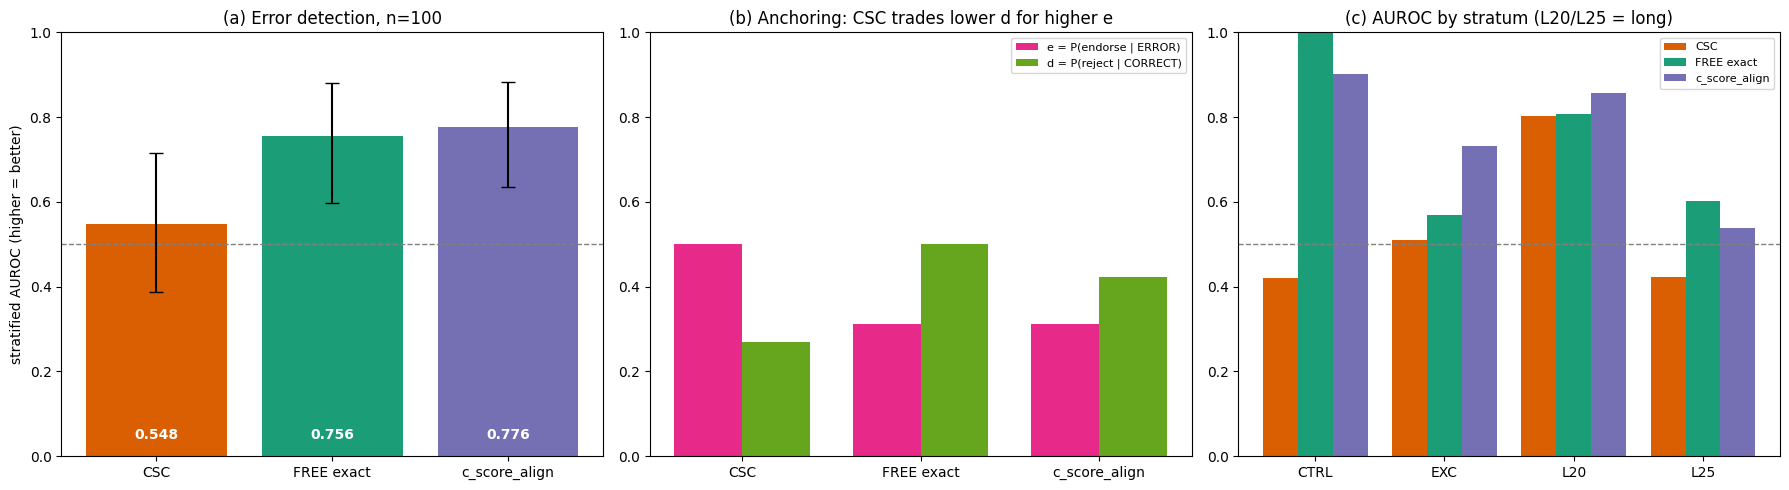

In [16]:
tab = pd.DataFrame([{"metric": v["name"], "strat_AUROC": round(v["strat_auroc"], 3),
                     "AUROC 95% CI": np.round(v["auroc_ci"], 3).tolist(), "pooled_AUROC": round(v["pooled_auroc"], 3),
                     "e = P(endorse|ERROR)": round(v["e"], 3), "d = P(reject|CORRECT)": round(v["d"], 3)}
                    for v in res.values()])
print(tab.to_string(index=False))
print(f"\npaired delta (CSC - FREE exact): {delta:+.3f}  CI {np.round(delta_ci, 3).tolist()}   (artifact PRIMARY: -0.156 [-0.290, -0.031])")

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
names = ["CSC", "FREE exact", "c_score_align"]
cols = ["#d95f02", "#1b9e77", "#7570b3"]
# (a) stratified AUROC with bootstrap CI
pts = [res[c]["strat_auroc"] for c in METRICS]
err = np.array([[p - res[c]["auroc_ci"][0], res[c]["auroc_ci"][1] - p] for p, c in zip(pts, METRICS)]).T
ax[0].bar(names, pts, color=cols, yerr=err, capsize=5)
ax[0].axhline(0.5, color="grey", ls="--", lw=1)
ax[0].set_ylim(0, 1); ax[0].set_ylabel("stratified AUROC (higher = better)")
ax[0].set_title(f"(a) Error detection, n={len(P)}")
for i, p in enumerate(pts):
    ax[0].text(i, 0.04, f"{p:.3f}", ha="center", color="white", fontweight="bold")
# (b) e and d
xx = np.arange(3); w = 0.38
ev_ = [res[c]["e"] for c in METRICS]; dv_ = [res[c]["d"] for c in METRICS]
ax[1].bar(xx - w / 2, ev_, w, label="e = P(endorse | ERROR)", color="#e7298a")
ax[1].bar(xx + w / 2, dv_, w, label="d = P(reject | CORRECT)", color="#66a61e")
ax[1].set_xticks(xx); ax[1].set_xticklabels(names); ax[1].set_ylim(0, 1); ax[1].legend(fontsize=8)
ax[1].set_title("(b) Anchoring: CSC trades lower d for higher e")
# (c) per-stratum AUROC
strata = ["CTRL", "EXC", "L20", "L25"]
for j, (c, col) in enumerate(zip(METRICS, cols)):
    vals = []
    for s_ in strata:
        m = P.stratum.values == s_
        vals.append(auc(P.y.values[m], P[c].values[m]) if 0 < P.y.values[m].sum() < m.sum() else np.nan)
    ax[2].bar(np.arange(4) + (j - 1) * 0.27, vals, 0.27, color=col, label=names[j])
ax[2].set_xticks(np.arange(4)); ax[2].set_xticklabels(strata); ax[2].axhline(0.5, color="grey", ls="--", lw=1)
ax[2].set_ylim(0, 1); ax[2].set_title("(c) AUROC by stratum (L20/L25 = long)"); ax[2].legend(fontsize=8)
plt.tight_layout()
plt.show()